# Task 5: Custom Batch Normalization and Layer Normalization
Manual forward and backward propagation using PyTorch tensors (Autograd disabled).

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)


In [2]:
class BatchNorm:
    def __init__(self, features, momentum=0.9, eps=1e-5):
        self.gamma = torch.ones(features)
        self.beta = torch.zeros(features)
        self.running_mean = torch.zeros(features)
        self.running_var = torch.ones(features)
        self.momentum = momentum
        self.eps = eps

    def forward(self, x, training=True):
        if training:
            self.mean = x.mean(dim=0)
            self.var = x.var(dim=0, unbiased=False)

            self.running_mean = self.momentum*self.running_mean + (1-self.momentum)*self.mean
            self.running_var = self.momentum*self.running_var + (1-self.momentum)*self.var
        else:
            self.mean = self.running_mean
            self.var = self.running_var

        self.x_hat = (x-self.mean)/torch.sqrt(self.var+self.eps)
        return self.gamma*self.x_hat + self.beta

    def backward(self, dout):
        N = dout.shape[0]

        dgamma = (dout*self.x_hat).sum(0)
        dbeta = dout.sum(0)

        dxhat = dout*self.gamma

        inv_std = 1/torch.sqrt(self.var+self.eps)

        dx = (1/N)*inv_std*(N*dxhat - dxhat.sum(0)
              - self.x_hat*(dxhat*self.x_hat).sum(0))

        return dx,dgamma,dbeta


In [3]:
class LayerNorm:
    def __init__(self, features, eps=1e-5):
        self.gamma = torch.ones(features)
        self.beta = torch.zeros(features)
        self.eps = eps

    def forward(self,x):
        self.mean=x.mean(dim=1,keepdim=True)
        self.var=x.var(dim=1,keepdim=True,unbiased=False)

        self.x_hat=(x-self.mean)/torch.sqrt(self.var+self.eps)

        return self.gamma*self.x_hat+self.beta

    def backward(self,dout):
        D=dout.shape[1]

        dgamma=(dout*self.x_hat).sum(0)
        dbeta=dout.sum(0)

        dxhat=dout*self.gamma

        inv_std=1/torch.sqrt(self.var+self.eps)

        dx=(1/D)*inv_std*(D*dxhat
            -dxhat.sum(1,keepdim=True)
            -self.x_hat*(dxhat*self.x_hat).sum(1,keepdim=True))

        return dx,dgamma,dbeta


In [4]:
X=torch.randn(8,16)

bn=BatchNorm(16)
ln=LayerNorm(16)

bn_out=bn.forward(X)
ln_out=ln.forward(X)

print("BatchNorm Output Shape:",bn_out.shape)
print("LayerNorm Output Shape:",ln_out.shape)

dout=torch.randn_like(bn_out)

bn_dx,bn_dg,bn_db=bn.backward(dout)
ln_dx,ln_dg,ln_db=ln.backward(dout)

print("\nBatchNorm")
print("dx:",bn_dx.shape)
print("dgamma:",bn_dg.shape)
print("dbeta:",bn_db.shape)

print("\nLayerNorm")
print("dx:",ln_dx.shape)
print("dgamma:",ln_dg.shape)
print("dbeta:",ln_db.shape)


BatchNorm Output Shape: torch.Size([8, 16])
LayerNorm Output Shape: torch.Size([8, 16])

BatchNorm
dx: torch.Size([8, 16])
dgamma: torch.Size([16])
dbeta: torch.Size([16])

LayerNorm
dx: torch.Size([8, 16])
dgamma: torch.Size([16])
dbeta: torch.Size([16])


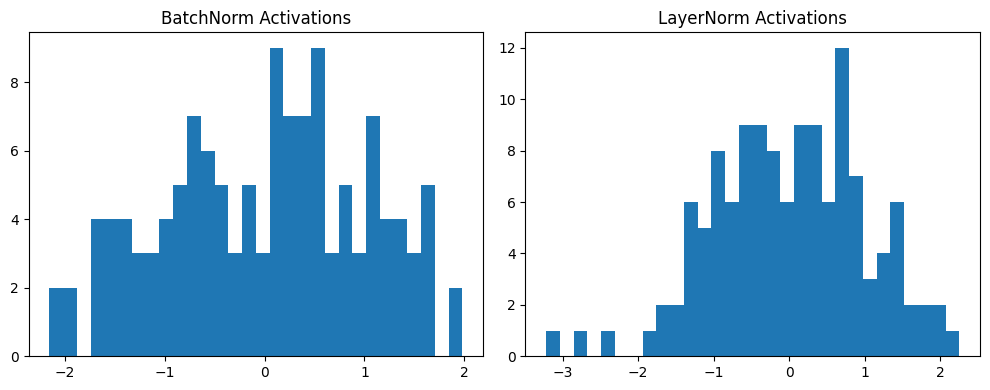

In [5]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(bn_out.numpy().flatten(),bins=30)
plt.title("BatchNorm Activations")

plt.subplot(1,2,2)
plt.hist(ln_out.numpy().flatten(),bins=30)
plt.title("LayerNorm Activations")

plt.tight_layout()
plt.show()
